## Analyze parameter estimation results for single enzyme reaction models fit to Pyruvate Kinase data
#### Nathaniel Linden - 2024-10-27

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import sys, json
import met_brewer as mb
from matplotlib.colors import LinearSegmentedColormap
import jax

# set plot style and import helper functions
plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Veronese", n=7)

# plotting helper functions
# add odes code
sys.path.append('../ampk_models/')
from plotting_helper_funcs import *
from utils import *

# set Jax to use 64-bit precision and CPU
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

save_path = '../../results/MA_v_MM/'

#### Load data + results

In [2]:
from scipy.interpolate import interp1d

# pyruvate kinase data
pyr_kin_dat = pd.read_csv('./data/Duggleby_Clarke_1991_Fig2.csv')
times = pyr_kin_dat['time'].to_numpy()
data = pyr_kin_dat['conc (mM)'].to_numpy()

# Create an interpolation function
interp_func = interp1d(times, data, kind='cubic')

# Generate new times with 10 points between each original point
new_times = np.linspace(times.min(), times.max(), len(times) * 10)

# Interpolate data at new times
new_data = interp_func(new_times)

# Save the new data and new times into a csv
interp_df = pd.DataFrame({'time': new_times, 'conc (mM)': new_data})
interp_df.to_csv('./data/Duggleby_Clarke_1991_Fig2_interp.csv', index=False)

In [3]:
# load inferences
inf_data_MA = az.from_netcdf('../../results/MA_v_MM/pyru_kin_/MA_mcmc_samples_pm.nc')
inf_data_MM = az.from_netcdf('../../results/MA_v_MM/pyru_kin_/MM_mcmc_samples_pm.nc')
inf_data_Hill = az.from_netcdf('../../results/MA_v_MM/pyru_kin_/Hill_mcmc_samples_pm.nc')

inf_data_Hill_prior = az.from_netcdf('../../results/MA_v_MM/pyru_kin_/Hill_prior_samples_pm.nc')

## Plots
1. Traces and marginals
2. Parameter estimate marginals
3. Prior/posterior predictive checks

#### Traces

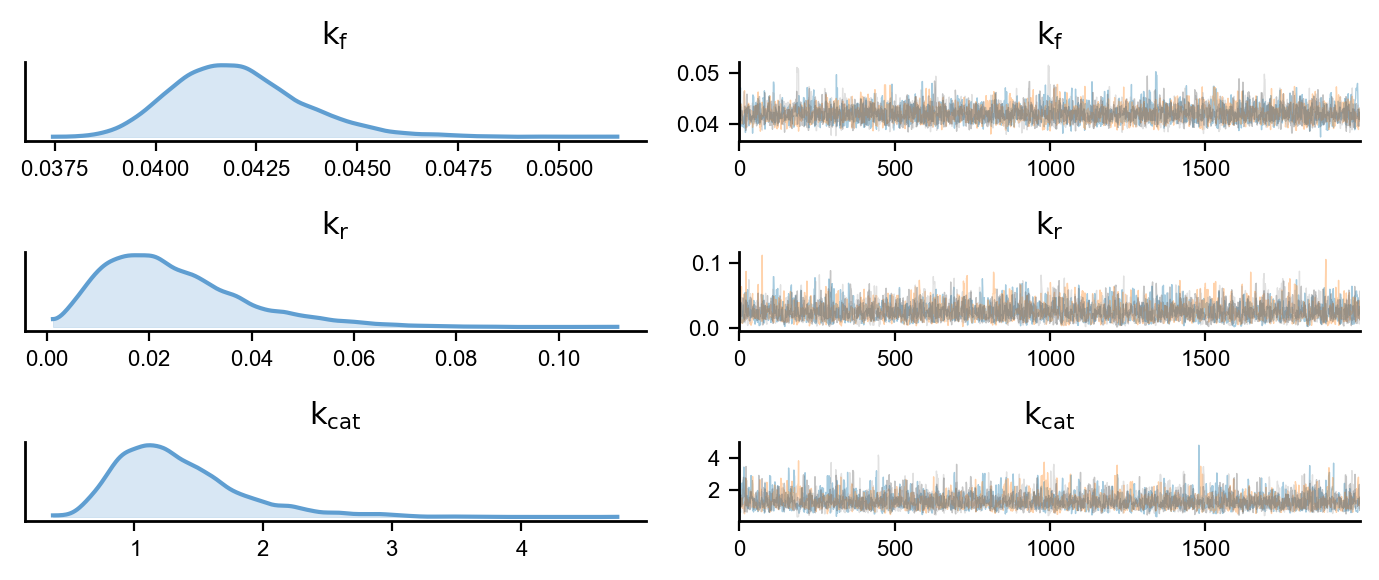

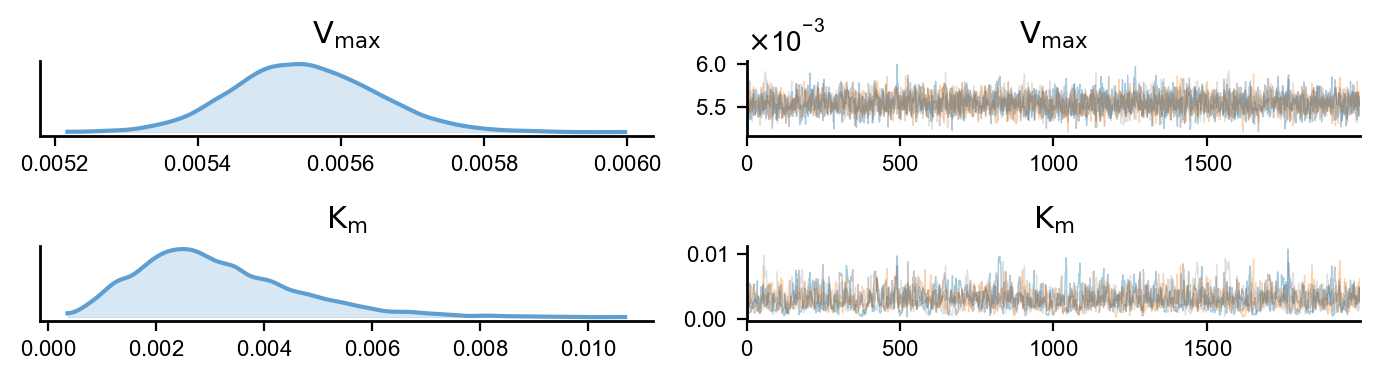

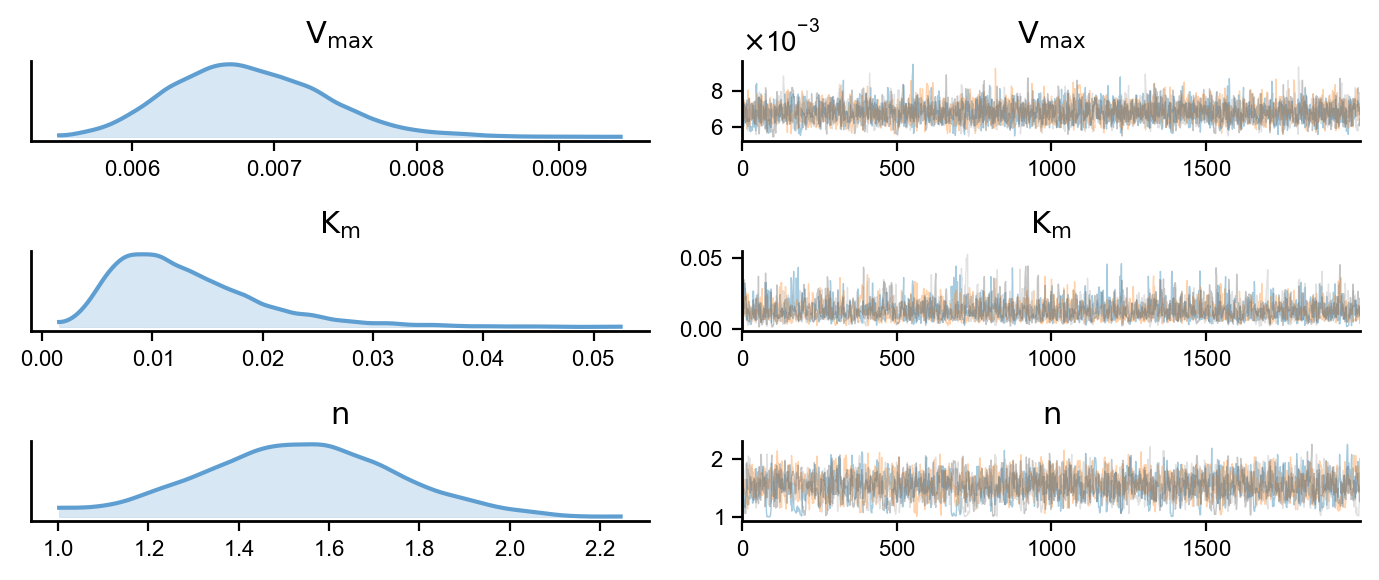

In [4]:
# MA
MA = az.plot_trace(inf_data_MA, figsize=(7, 3), compact=True, divergences=False, 
                   combined=True, chain_prop='color', fill_kwargs={'alpha': 0.24},
                   trace_kwargs={'linewidth': 0.5})
param_names = {'k_f': r'$k_f$', 'k_r': r'$k_r$', 'k_cat': r'$k_{cat}$', 'V_max': r'$V_{max}$', 'K_m': r'$K_m$', 'n': r'$n$'}
for ax in MA.ravel():
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_title(param_names[ax.get_title()], fontsize=11, fontweight='bold')
plt.savefig(save_path + 'MA_trace.png', dpi=500)

# MM
MM = az.plot_trace(inf_data_MM, figsize=(7, 2), compact=True, divergences=False, 
                   combined=True, chain_prop='color',fill_kwargs={'alpha': 0.24},
                   trace_kwargs={'linewidth': 0.5})
for ax in MM.ravel():
    # ax.set_xticklabels(fontsize=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.set_title(param_names[ax.get_title()], fontsize=11, fontweight='bold')
    ax.ticklabel_format(style='plain', axis='x')
plt.savefig(save_path + 'MM_trace.png', dpi=500)

# Hill
hill = az.plot_trace(inf_data_Hill, figsize=(7, 3), compact=True, divergences=False, 
                     combined=True, chain_prop='color',fill_kwargs={'alpha': 0.24},
                     trace_kwargs={'linewidth': 0.5})
for ax in hill.ravel():
    # ax.set_xticklabels(fontsize=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.set_title(param_names[ax.get_title()], fontsize=11, fontweight='bold')
    ax.ticklabel_format(style='plain', axis='x')
plt.savefig(save_path + 'hill_trace.png', dpi=500)

#### MCMC Convergence Metrics

In [5]:
print('Mass Action:')
print(az.summary(inf_data_MA, kind='diagnostics'))

print('Michaelis-Menten:')
print(az.summary(inf_data_MM, kind='diagnostics'))

print('Hill:')
print(az.summary(inf_data_Hill, kind='diagnostics'))

Mass Action:
       mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
k_f        0.000    0.000    4619.0    3911.0    1.0
k_r        0.000    0.000    3943.0    2596.0    1.0
k_cat      0.008    0.006    3963.0    3206.0    1.0
Michaelis-Menten:
       mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
V_max        0.0      0.0    2527.0    3231.0    1.0
K_m          0.0      0.0    1221.0    1345.0    1.0
Hill:
       mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
V_max      0.000    0.000    3148.0    3035.0    1.0
K_m        0.000    0.000    2203.0    2359.0    1.0
n          0.006    0.004    1453.0     966.0    1.0


#### marginal distributions of the parameter estimates:

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_27393/4119105406.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_27393/4119105406.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MM_hist.pdf', transparent=True, bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_27393/4119105406.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'Hill_hist.pdf', transparent=True, bbox_inches='tight')
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tigh

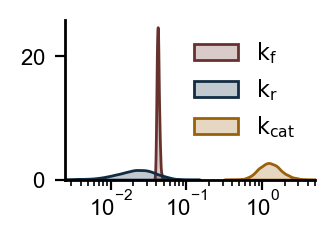

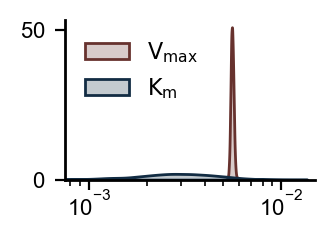

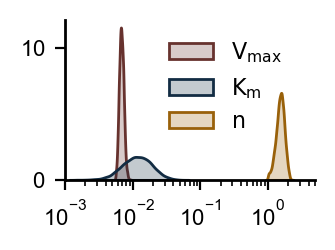

In [6]:
# MA
MA_names = {'k_cat': r'$k_{cat}$', 'k_f': r'$k_{f}$', 'k_r': r'$k_{r}$',}
fig, ax = get_sized_fig_ax(1.25, 0.8)
for idx,param in enumerate(list(inf_data_MA.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_MA.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=MA_names[param], linewidth=1.0, log_scale=True)
ax.set_xlabel('', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8)
ax.xaxis.set_tick_params(pad=0)
ax.set_xlim(2.5e-3, 5e0)
plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')

# MM
MM_names = {'V_max': r'$V_{max}$', 'K_m': r'$K_{m}$',}
fig, ax = get_sized_fig_ax(1.25, 0.8)
for idx,param in enumerate(list(inf_data_MM.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_MM.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=MM_names[param], linewidth=1.0, log_scale=True)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_xlabel('', fontsize=8)
ax.set_ylabel('', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8, loc='upper left')
ax.xaxis.set_tick_params(pad=0)
ax.set_xlim(7.5e-4, 1.5e-2)
plt.savefig(save_path + 'MM_hist.pdf', transparent=True, bbox_inches='tight')

# Hill
Hill_names = {'V_max': r'$V_{max}$   ', 'K_m': r'$K_{m}$', 'n': r'$n$'}
fig, ax = get_sized_fig_ax(1.25, 0.8)
for idx,param in enumerate(list(inf_data_Hill.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_Hill.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=Hill_names[param], linewidth=1.0, log_scale=True)
ax.set_xlabel('', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8, ncol=1)
ax.set_xlim(1e-3, 5e0)
plt.savefig(save_path + 'Hill_hist.pdf', transparent=True, bbox_inches='tight')


#### Prior/posterior predictive checks

/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/mass-action_vs_michaelis-menten/../ampk_models/plotting_helper_funcs.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research/Project_3_AMPK/src/mass-action_vs_michaelis-menten/../ampk_models/plotting_helper_funcs.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(filename, dpi="figure", bbox_inches=bbox)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_27393/663033646.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_MA.savefig(save_path + 'MA_predictive.pdf', transparent=True, bbox_inches='tight')
/Users/natetest/Library/CloudStorage/Dropbox/Mac (2)/Documents/phd/research

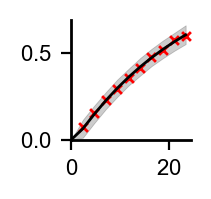

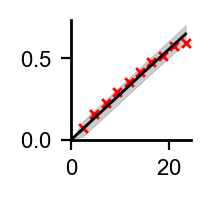

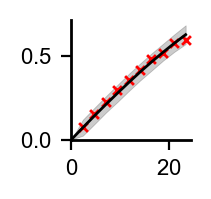

In [7]:
f_size = (0.6, 0.6)

fig_MA, ax_MA, leg_MA = plot_predictive(inf_data_MA, data, times, plot_prior=False, n_traces=0,
                          figsize=f_size, cred_int=99)
export_legend(leg_MA, save_path + 'MA_predictive_legend.pdf')
leg_MA.remove()
fig_MA.savefig(save_path + 'MA_predictive.pdf', transparent=True, bbox_inches='tight')

fig_MM, ax_MM, leg_MM = plot_predictive(inf_data_MM, data, times, plot_prior=False, n_traces=0,
                            figsize=f_size, cred_int=99)
export_legend(leg_MM, save_path + 'MM_predictive_legend.pdf')
leg_MM.remove()
fig_MM.savefig(save_path + 'MM_predictive.pdf', transparent=True, bbox_inches='tight')

fig_Hill, ax_Hill, leg_Hill = plot_predictive(inf_data_Hill, data, times, plot_prior=False, n_traces=0,
                            figsize=f_size, cred_int=99)
export_legend(leg_Hill, save_path + 'Hill_predictive_legend.pdf')
leg_Hill.remove()
fig_Hill.savefig(save_path + 'Hill_predictive.pdf', transparent=True, bbox_inches='tight')


#### Compute ELPPD for model comparison

In [8]:
print("The PSIS_LOO_CV estimate of the ELPD for the MA model is: ", az.loo(inf_data_MA))
print("The PSIS_LOO_CV estimate of the ELPD for the MM model is: ", az.loo(inf_data_MM))
print("The PSIS_LOO_CV estimate of the ELPD for the Hill model is: ", az.loo(inf_data_Hill))

The PSIS_LOO_CV estimate of the ELPD for the MA model is:  Computed from 8000 posterior samples and 10 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    29.09     0.26
p_loo        0.39        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       10  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

The PSIS_LOO_CV estimate of the ELPD for the MM model is:  Computed from 8000 posterior samples and 10 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    17.87     5.01
p_loo        3.14        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)        9   90.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         1   10.0%
   (1, Inf)   (very bad)    0    0.0%

The PSIS_LOO_CV estimate of 

/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [9]:
inf_data_MA

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data